# Manual Pipeline Test: RA Cohort from MIMIC-IV via MAP

End-to-end run of the phenotyping pipeline for the agent task:
> *"Build a cohort of rheumatoid arthritis patients from MIMIC-IV."*

**Pipeline stages:**
1. Load MIMIC-IV raw EHR data
2. ONCE — discover codified (PheCode) and NLP (CUI) features for RA
3. ICD → PheCode rollup ()
4. Build MAP feature matrix
5. NLP feature extraction via  *(requires MIMIC-IV-Note; skipped here)*
6. Run MAP algorithm → per-patient phenotype scores
7. Inspect and validate the resulting RA cohort

**Notes on data availability:**
- Standard MIMIC-IV () does not include clinical note text (that is in MIMIC-IV-Note, a separate module).
  Hospital admission counts are used as a proxy for note counts.
- NLP cells are shown for completeness but gated behind .

In [ ]:
import os
import sys
import pandas as pd
from matplotlib import pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────
# Notebook lives in bmi702-project/m4-pheno/; MIMIC data is one level up.
NOTEBOOK_DIR = os.path.abspath(".")
PROJECT_DIR = os.path.abspath("..")
MIMIC_DIR = os.path.join(PROJECT_DIR, "mimiciv", "hosp")

# Add m4-pheno to sys.path so local modules import without install
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

PHECODE_MAP = os.path.join(NOTEBOOK_DIR, "Phecode_map_v1_2_icd9_icd10cm.csv")
ONCE_CODIFIED = os.path.join(
    NOTEBOOK_DIR, "ONCE_Rheumatoid Arthritis_PheCode714.1_cos0.165.csv"
)
ONCE_NARRATIVE = os.path.join(
    NOTEBOOK_DIR,
    "ONCE_Rheumatoid Arthritis_C0003873_titlecos0.5_titlecut0.3_exactFALSE.csv",
)

# Toggle: set True only if MIMIC-IV-Note is available under mimiciv/note/
NOTES_AVAILABLE = False
NOTES_FILE = os.path.join(PROJECT_DIR, "mimiciv", "note", "discharge.csv.gz")

print("MIMIC_DIR  :", MIMIC_DIR, "-> exists:", os.path.isdir(MIMIC_DIR))
print(
    "PHECODE_MAP:",
    os.path.basename(PHECODE_MAP),
    "-> exists:",
    os.path.isfile(PHECODE_MAP),
)
print(
    "ONCE_COD   :",
    os.path.basename(ONCE_CODIFIED),
    "-> exists:",
    os.path.isfile(ONCE_CODIFIED),
)
print(
    "ONCE_NAR   :",
    os.path.basename(ONCE_NARRATIVE),
    "-> exists:",
    os.path.isfile(ONCE_NARRATIVE),
)

MIMIC_DIR  : /Users/irithkatiyar/Desktop/bmi702/bmi702-project/mimiciv/hosp -> exists: True
PHECODE_MAP: Phecode_map_v1_2_icd9_icd10cm.csv -> exists: True
ONCE_COD   : ONCE_Rheumatoid Arthritis_PheCode714.1_cos0.165.csv -> exists: True
ONCE_NAR   : ONCE_Rheumatoid Arthritis_C0003873_titlecos0.5_titlecut0.3_exactFALSE.csv -> exists: True


## Step 1 — Load MIMIC-IV EHR Data

In [2]:
# ICD diagnosis codes — core input for the rollup step
diagnoses_df = pd.read_csv(
    os.path.join(MIMIC_DIR, "diagnoses_icd.csv.gz"),
    dtype={"icd_code": str, "icd_version": int},
)
print(
    f"diagnoses_icd : {len(diagnoses_df):>10,} rows  |  "
    f"{diagnoses_df['subject_id'].nunique():,} unique patients"
)
diagnoses_df.head(100)

diagnoses_icd :  6,364,488 rows  |  223,291 unique patients


,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9
...,...,...,...,...,...
95,10000635,20642640,8,I471,10
96,10000635,20642640,9,Z20822,10
97,10000635,26134563,1,42789,9
98,10000635,26134563,2,25000,9


In [3]:
# Admissions — used as a proxy for note count (1 admission ~ 1 discharge note).
# MAP needs a note count per patient; without MIMIC-IV-Note, admission count
# is the closest available signal from standard MIMIC-IV.
admissions_df = pd.read_csv(
    os.path.join(MIMIC_DIR, "admissions.csv.gz"),
    usecols=["subject_id", "hadm_id"],
)
print(
    f"admissions : {len(admissions_df):>10,} rows  |  "
    f"{admissions_df['subject_id'].nunique():,} unique patients"
)
admissions_df.head()

admissions :    546,028 rows  |  223,452 unique patients


,subject_id,hadm_id
0,10000032,22595853
1,10000032,22841357
2,10000032,25742920
3,10000032,29079034
4,10000068,25022803


## Step 2 — ONCE: Automated Feature Discovery for RA

 reads the two ONCE output files and returns:
- **** — high-confidence PheCode features (the MAP feature set)
- **** — CUI + term pairs for MedSpaCy NER

> **Known issue with :**  reads the narrative file with 
> but the ONCE narrative CSV in this project is comma-separated, so  comes
> back empty. The cell below re-reads the narrative file with the correct separator.

In [4]:
from once import get_once_features

once_features = get_once_features(ONCE_CODIFIED, ONCE_NARRATIVE)

print("=== Codified features ===")
print(f"  Total rows           : {len(once_features['codified'])}")
print(f"  phenotyping_features : {len(once_features['codified_list'])}")
print(f"  Sample               : {once_features['codified_list'][:5]}")

print("=== Narrative features ===")
print(
    f"  nlp_target_cuis from once.py : {len(once_features['nlp_target_cuis'])} "
    "(expected 0 -- sep='|' mismatch)"
)

# Fix: re-read narrative file with correct comma separator
narrative_df = pd.read_csv(ONCE_NARRATIVE)
# once.py expects columns 'CUI' / 'Term'; actual columns are lowercase
narrative_df.columns = [c.upper() for c in narrative_df.columns]
nlp_target_cuis = [
    {"term": row["TERM"], "cui": row["CUI"]}
    for _, row in narrative_df[["TERM", "CUI"]].dropna().iterrows()
]
print(f"  nlp_target_cuis after manual load : {len(nlp_target_cuis)}")
print(f"  Sample : {nlp_target_cuis[:3]}")

print("=== Full ONCE codified table ===")
once_features["codified"]

=== Codified features ===
  Total rows           : 278
  phenotyping_features : 41
  Sample               : ['PheCode:714.1', 'PheCode:714.2', 'PheCode:716.1', 'PheCode:041.21', 'RXNORM:614391']
=== Narrative features ===
  nlp_target_cuis from once.py : 0 (expected 0 -- sep='|' mismatch)
  nlp_target_cuis after manual load : 442
  Sample : [{'term': 'Rheumatoid Arthritis', 'cui': 'C0003873'}, {'term': 'Rheumatoid Nodule', 'cui': 'C0035450'}, {'term': 'Seropositive rheumatoid arthritis', 'cui': 'C0409651'}]
=== Full ONCE codified table ===


,Variable,Description,target_similarity,importance_score,phenotyping_features,expanded_features
0,PheCode:714.1,rheumatoid arthritis,1.000,0.631,True,True
1,PheCode:714.2,juvenile rheumatoid arthritis,0.533,0.429,True,True
2,PheCode:716.1,unspecified polyarthropathy or polyarthritis,0.502,0.399,True,True
3,PheCode:041.21,rheumatic fever / chorea,0.424,0.393,True,True
4,RXNORM:614391,abatacept,0.469,0.392,True,True
...,...,...,...,...,...,...
273,RXNORM:6038,isoniazid,0.173,0.067,False,False
274,RXNORM:709271,certolizumab,0.257,NaN,False,False
275,ShortName:Mono - Fra,mono - fra,0.194,NaN,False,False
276,ShortName:MCV,mcv,0.193,NaN,False,False


In [5]:
# Extract PheCode features (strip 'PheCode:' prefix to match pivot column names after rollup)
once_phecodes_raw = [
    v for v in once_features["codified_list"] if v.startswith("PheCode:")
]
once_phecodes = [v.replace("PheCode:", "") for v in once_phecodes_raw]

print(f"ONCE PheCode features : {len(once_phecodes)}")
print(once_phecodes)

MAIN_ICD_COL = "714.1"  # primary RA MAP anchor
assert MAIN_ICD_COL in once_phecodes, "Main anchor must be in ONCE codified list"

ONCE PheCode features : 28
['714.1', '714.2', '716.1', '041.21', '714', '716.8', '696.42', '740.12', '740.2', '709.2', '715.2', '711.2', '274.2', '717', '709.7', '727.2', '710.2', '446.9', '739', '274.11', '716.9', '446.6', '741.5', '741.6', '711.1', '729.1', '696.4', '726.3']


## Step 3 — ICD → PheCode Rollup

Maps every ICD-9/ICD-10 code in  to a PheCode.
Codes with or without a decimal point are both handled ( normalises at position 3).

In [6]:
from rollup import rollup_icd_to_phecode

phecode_df = rollup_icd_to_phecode(
    diagnoses_df,
    icd_column="icd_code",
    mapping_file=PHECODE_MAP,
)

n_mapped = phecode_df["Phecode"].notna().sum()
n_unmapped = phecode_df["Phecode"].isna().sum()
print(f"Total rows          : {len(phecode_df):,}")
print(f"Mapped to PheCode   : {n_mapped:,}  ({100 * n_mapped / len(phecode_df):.1f}%)")
print(f"Unmapped (no entry) : {n_unmapped:,}")

ra_raw = phecode_df[phecode_df["Phecode"] == MAIN_ICD_COL]
print(f"Patients with PheCode {MAIN_ICD_COL} (RA): {ra_raw['subject_id'].nunique():,}")

phecode_df[["subject_id", "icd_code", "icd_version", "Phecode", "PhecodeString"]].head(
    10
)

Total rows          : 6,443,112
Mapped to PheCode   : 5,943,457  (92.2%)
Unmapped (no entry) : 499,655
Patients with PheCode 714.1 (RA): 3,477


,subject_id,icd_code,icd_version,Phecode,PhecodeString
0,10000032,572.3,9,571.81,Portal hypertension
1,10000032,789.59,9,572,Ascites (non malignant)
2,10000032,571.5,9,571.51,Cirrhosis of liver without mention of alcohol
3,10000032,070.70,9,070.3,Viral hepatitis C
4,10000032,496,9,496,Chronic airway obstruction
5,10000032,296.80,9,296.1,Bipolar
6,10000032,309.81,9,300.9,Posttraumatic stress disorder
7,10000032,V15.82,9,318,Tobacco use disorder
8,10000032,070.71,9,070.3,Viral hepatitis C
9,10000032,789.59,9,572,Ascites (non malignant)


## Step 4 — Build MAP Feature Matrix

**** — wide patient × ONCE-PheCode count matrix. Only patients with at least one
ONCE-identified PheCode are included; this scopes the population to individuals with RA signal.

**** — admission count per patient (proxy for note count).

In [7]:
# Full PheCode pivot (all patients x all PheCodes)
mapped = phecode_df.dropna(subset=["Phecode"])
all_phecode_wide = mapped.pivot_table(
    index="subject_id",
    columns="Phecode",
    aggfunc="size",
    fill_value=0,
)
print(
    f"Full pivot : {all_phecode_wide.shape[0]:,} patients x {all_phecode_wide.shape[1]:,} PheCodes"
)

# Restrict columns to ONCE-identified PheCodes present in the data
available_once_cols = [c for c in once_phecodes if c in all_phecode_wide.columns]
missing_once_cols = [c for c in once_phecodes if c not in all_phecode_wide.columns]
print(f"ONCE PheCodes available : {len(available_once_cols)} / {len(once_phecodes)}")
if missing_once_cols:
    print(f"Not in MIMIC-IV data    : {missing_once_cols}")

# Main anchor always first column
feature_cols = [MAIN_ICD_COL] + [c for c in available_once_cols if c != MAIN_ICD_COL]
mat_full = all_phecode_wide[feature_cols]

# Keep patients with at least one ONCE-feature occurrence
mat_df = mat_full[mat_full.sum(axis=1) > 0].copy()
print(f"Study population : {mat_df.shape[0]:,} patients x {mat_df.shape[1]} features")
print(f"  With >= 1 RA PheCode ({MAIN_ICD_COL}) : {(mat_df[MAIN_ICD_COL] > 0).sum():,}")
mat_df.head()

Full pivot : 222,960 patients x 1,785 PheCodes
ONCE PheCodes available : 27 / 28
Not in MIMIC-IV data    : ['696.4']
Study population : 12,476 patients x 27 features
  With >= 1 RA PheCode (714.1) : 3,477


Phecode,714.1,714.2,716.1,041.21,714,716.8,696.42,740.12,740.2,709.2,...,446.9,739,274.11,716.9,446.6,741.5,741.6,711.1,729.1,726.3
subject_id,,,,,,,,,,,,,,,,,,,,,
10002013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10002428,0,0,0,0,0,0,0,0,0,7,...,0,0,0,0,0,0,0,0,0,0
10002443,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10002769,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10002976,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [8]:
# note_df: admissions per patient as proxy for discharge note count
note_df = admissions_df.groupby("subject_id").size().to_frame("note_count")
# Align to study population; patients absent from admissions get count of 1
note_df = note_df.reindex(mat_df.index).fillna(1).astype(int)

print(f"note_df : {len(note_df):,} patients")
print(note_df.describe().T)

note_df : 12,476 patients
              count      mean       std  min  25%  50%  75%    max
note_count  12476.0  4.767714  6.697918  1.0  1.0  3.0  5.0  103.0


## Step 5 — NLP Feature Extraction via 

Extracts CUI mentions from clinical discharge notes using MedSpaCy,
targeting the CUI vocabulary returned by ONCE.

**Skipped** — MIMIC-IV-Note is not present in .
Set  in the setup cell and point  at
 (columns: , ) to enable.

In [9]:
if NOTES_AVAILABLE:
    from note_ner import extract_cui_features, aggregate_features

    notes_df = pd.read_csv(NOTES_FILE, usecols=["subject_id", "text"])
    notes_df = notes_df[notes_df["subject_id"].isin(mat_df.index)]

    # Override note_df with real note counts
    note_df = (
        notes_df.groupby("subject_id")
        .size()
        .to_frame("note_count")
        .reindex(mat_df.index)
        .fillna(0)
        .astype(int)
    )

    cui_long = extract_cui_features(
        notes_df,
        text_column="text",
        id_column="subject_id",
        target_cuis=nlp_target_cuis,  # built from ONCE narrative above
    )
    print(
        f"CUI mentions : {len(cui_long):,} rows  across  {cui_long['subject_id'].nunique():,} patients"
    )

    cui_wide = aggregate_features(
        cui_long, id_column="subject_id", feature_column="cui"
    )
    mat_df = mat_df.join(cui_wide, how="left").fillna(0)
    print(f"mat_df with NLP : {mat_df.shape}")
else:
    print("NOTES_AVAILABLE=False -- NLP step skipped.")
    print(f"mat_df uses PheCode features only: {mat_df.shape}")

NOTES_AVAILABLE=False -- NLP step skipped.
mat_df uses PheCode features only: (12476, 27)


## Step 6 — Run MAP

MAP fits a Poisson/normal mixture model to distinguish true RA cases from background.

-  index must be 
-  must have a  column with the same index
-  must exactly match a column name in  — dots in the name are fine

In [12]:
# ── Pre-MAP validation & feature filter ────────────────────────────────────
# MAP fits a *per-feature* univariate Poisson mixture and excludes zero-count
# patients for each fit.  If a feature has only 1–9 non-zero patients, flexmix
# cannot form 2 components → "Log-likelihood: NA" on iteration 1.
# Fix: drop features with fewer than MIN_NONZERO non-zero patients (keep anchor).

MIN_NONZERO = 20  # minimum non-zero patient count per feature

nonzero_counts = (mat_df > 0).sum().sort_values()
sparse_cols = nonzero_counts[
    (nonzero_counts < MIN_NONZERO) & (nonzero_counts.index != MAIN_ICD_COL)
].index.tolist()

if sparse_cols:
    print(
        f"Dropping {len(sparse_cols)} sparse features (< {MIN_NONZERO} non-zero patients):"
    )
    for c in sparse_cols:
        print(f"  {c:12s}  non-zero patients = {int(nonzero_counts[c])}")
    mat_df = mat_df.drop(columns=sparse_cols)

print(f"\nmat_df after filter : {mat_df.shape}")
print("Non-zero counts per feature:")
print((mat_df > 0).sum().sort_values().to_string())

# Rebuild note_df aligned to current mat_df
note_df = (
    admissions_df.groupby("subject_id")
    .size()
    .to_frame("note_count")
    .reindex(mat_df.index)
    .fillna(1)
    .clip(lower=1)
    .astype(int)
)
print(f"\nnote_df zeros : {(note_df['note_count'] == 0).sum()}")
print(f"'{MAIN_ICD_COL}' non-zero patients : {(mat_df[MAIN_ICD_COL] > 0).sum():,}")

Dropping 4 sparse features (< 20 non-zero patients):
  710.2         non-zero patients = 1
  729.1         non-zero patients = 9
  741.6         non-zero patients = 13
  716.8         non-zero patients = 17

mat_df after filter : (12476, 23)
Non-zero counts per feature:
Phecode
041.21      24
711.2       50
274.2       56
716.1       63
714.2       99
446.6      105
709.7      133
727.2      139
741.5      191
714        243
740.12     263
715.2      276
739        326
446.9      331
740.2      338
726.3      356
709.2      541
696.42     630
711.1     1214
274.11    1222
717       1342
716.9     2617
714.1     3477

note_df zeros : 0
'714.1' non-zero patients : 3,477


In [13]:
from map import run_map

print("Calling run_map with:")
print(f"  mat_df       : {mat_df.shape}  (index={mat_df.index.name})")
print(f"  note_df      : {note_df.shape}")
print(f"  main_icd_col : '{MAIN_ICD_COL}'")

map_results = run_map(mat_df, note_df, main_icd_col=MAIN_ICD_COL)

print(f"MAP finished. Output shape: {map_results.shape}")
map_results.head(10)

Calling run_map with:
  mat_df       : (12476, 23)  (index=subject_id)
  note_df      : (12476, 1)
  main_icd_col : '714.1'
MAP finished. Output shape: (12476, 3)


,patient_id,score,phenotype
0,10002013,0.000000,0
1,10002428,0.000000,0
2,10002443,0.268220,0
3,10002769,0.000000,0
4,10002976,0.000000,0
5,10003203,0.255806,0
6,10005817,0.000000,0
7,10005858,0.000000,0
8,10006513,0.000000,0
9,10006580,0.000000,0


## Step 7 — Inspect and Validate the RA Cohort

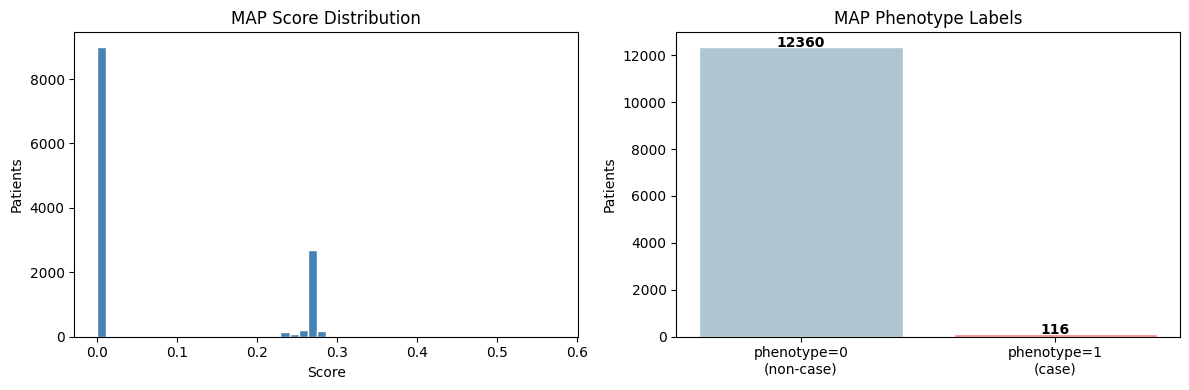

count    12476.000000
mean         0.074926
std          0.121045
min          0.000000
25%          0.000000
50%          0.000000
75%          0.254903
max          0.572936
Name: score, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(map_results["score"], bins=50, edgecolor="white", color="steelblue")
axes[0].set_title("MAP Score Distribution")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Patients")

counts = map_results["phenotype"].value_counts().sort_index()
axes[1].bar(
    ["phenotype=0\n(non-case)", "phenotype=1\n(case)"],
    counts.values,
    color=["#aec6cf", "#ff7f7f"],
    edgecolor="white",
)
axes[1].set_title("MAP Phenotype Labels")
axes[1].set_ylabel("Patients")
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print(map_results["score"].describe())

In [15]:
# Sanity check: MAP cases should have higher RA ICD code counts than controls
scored = map_results.set_index("patient_id")
cases = scored[scored["phenotype"] == 1].index
controls = scored[scored["phenotype"] == 0].index

ra_counts = mat_df[MAIN_ICD_COL].rename("ra_phecode_count")
case_ra = ra_counts.reindex(cases).fillna(0)
ctrl_ra = ra_counts.reindex(controls).fillna(0)

print(f"=== PheCode {MAIN_ICD_COL} count -- MAP cases vs. controls ===")
print(
    f"  Cases    n={len(cases):,}    mean={case_ra.mean():.2f}  median={case_ra.median():.0f}"
)
print(
    f"  Controls n={len(controls):,}  mean={ctrl_ra.mean():.2f}  median={ctrl_ra.median():.0f}"
)
print(f"% MAP cases with >= 1 RA ICD code : {(case_ra > 0).mean() * 100:.1f}%")

=== PheCode 714.1 count -- MAP cases vs. controls ===
  Cases    n=116    mean=8.15  median=4
  Controls n=12,360  mean=0.59  median=0
% MAP cases with >= 1 RA ICD code : 100.0%


In [16]:
# Top 20 highest-scoring patients with RA ICD count and admission count
top_cases = (
    scored[["score", "phenotype"]]
    .join(mat_df[[MAIN_ICD_COL]].rename(columns={MAIN_ICD_COL: "ra_icd_count"}))
    .join(note_df.rename(columns={"note_count": "admissions"}))
    .sort_values("score", ascending=False)
    .head(20)
)
print("Top 20 patients by MAP score:")
top_cases

Top 20 patients by MAP score:


,score,phenotype,ra_icd_count,admissions
patient_id,,,,
15080981,0.572936,1,4,24
15261136,0.521908,1,4,38
11152968,0.509331,1,1,14
12902597,0.473559,1,1,15
17295976,0.469794,1,2,83
11778596,0.442566,1,1,14
14128867,0.430427,1,6,6
15717841,0.430044,1,5,5
13009523,0.429695,1,4,4


In [17]:
n_cases = int((map_results["phenotype"] == 1).sum())
prevalence = n_cases / len(map_results) * 100

print("=" * 50)
print("RA COHORT SUMMARY (MAP)")
print("=" * 50)
print(f"Study population        : {len(map_results):,} patients")
print(f"MAP cases (phenotype=1) : {n_cases:,}")
print(f"Estimated prevalence    : {prevalence:.1f}%")
print(f"Feature matrix          : {mat_df.shape[1]} ONCE features (PheCode)")
if NOTES_AVAILABLE:
    n_cui = sum(1 for c in mat_df.columns if c.startswith("C"))
    print(f"  + {n_cui} CUI (NLP) features")
print(
    f"Note count source       : {'MIMIC-IV-Note discharge notes' if NOTES_AVAILABLE else 'admission count (proxy)'}"
)

RA COHORT SUMMARY (MAP)
Study population        : 12,476 patients
MAP cases (phenotype=1) : 116
Estimated prevalence    : 0.9%
Feature matrix          : 23 ONCE features (PheCode)
Note count source       : admission count (proxy)
